<a href="https://colab.research.google.com/github/NesrineTahmi/smartphone-addiction-prediction/blob/main/smartphone_addiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA**

Competition: predict `addicted_label` probability for each `id` in the test set. Evaluated on **ROC AUC**.


# Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

print("all imported !")


all imported !


# Load Data

In [2]:
TRAIN_PATH = "../data/train.csv"
TEST_PATH = "../data/test.csv"
SAMPLE_SUB_PATH = "../data/sample_submission.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUB_PATH)

TARGET = "addicted_label"
ID_COL = "id"

print(train.shape, test.shape, sample_submission.shape)
train.head()


(691369, 14) (296302, 13) (296302, 2)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


# Exploratory Data Analysis (EDA)

In [3]:
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183467,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [4]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 296302 entries, 0 to 296301
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       296302 non-null  int64  
 1   age                      279164 non-null  float64
 2   daily_screen_time_hours  263514 non-null  float64
 3   social_media_hours       248905 non-null  float64
 4   gaming_hours             236882 non-null  float64
 5   work_study_hours         268525 non-null  float64
 6   sleep_hours              273847 non-null  float64
 7   notifications_per_day    262081 non-null  float64
 8   app_opens_per_day        270597 non-null  float64
 9   weekend_screen_time      245605 non-null  float64
 10  gender                   282090 non-null  str    
 11  stress_level             276676 non-null  str    
 12  academic_work_impact     270581 non-null  str    
dtypes: float64(9), int64(1), str(3)
memory usage: 29.4 MB


In [5]:
# Sanity checks
print("ID overlap between train/test:", set(train[ID_COL]).intersection(set(test[ID_COL])))
print("Columns in train not in test:", set(train.columns) - set(test.columns))
print("Columns in test not in train:", set(test.columns) - set(train.columns))

ID overlap between train/test: set()
Columns in train not in test: {'addicted_label'}
Columns in test not in train: set()


## Target Balance

addicted_label
1    490474
0    200895
Name: count, dtype: int64
addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64


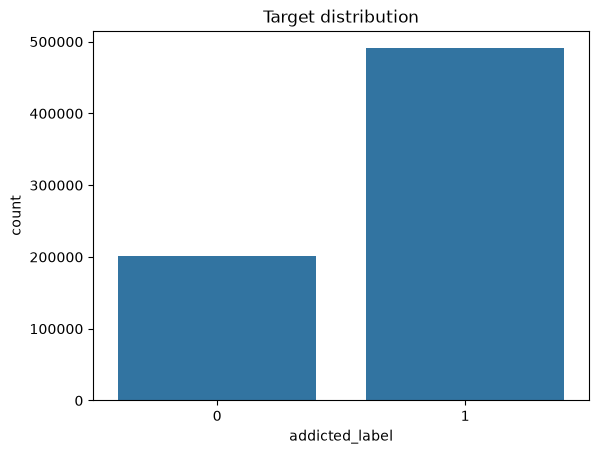

In [6]:
print(train[TARGET].value_counts())
print(train[TARGET].value_counts(normalize=True))

sns.countplot(data=train, x=TARGET)
plt.title("Target distribution")
plt.show()

## Missing values

In [7]:
train_missing = train.isnull().sum().sort_values(ascending=False)
test_missing = test.isnull().sum().sort_values(ascending=False)

print("Train missing values:")
print(train_missing[train_missing > 0])
print()
print("Test missing values:")
print(test_missing[test_missing > 0])

Train missing values:
social_media_hours         133995
gaming_hours               126821
weekend_screen_time        112063
daily_screen_time_hours     95854
app_opens_per_day           80710
notifications_per_day       67584
stress_level                55148
work_study_hours            51518
sleep_hours                 44480
academic_work_impact        44224
gender                      29034
age                         28929
dtype: int64

Test missing values:
gaming_hours               59420
weekend_screen_time        50697
social_media_hours         47397
notifications_per_day      34221
daily_screen_time_hours    32788
work_study_hours           27777
academic_work_impact       25721
app_opens_per_day          25705
sleep_hours                22455
stress_level               19626
age                        17138
gender                     14212
dtype: int64


## Numeric vs categorical columns

In [8]:
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET]]

numeric_features = train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
Categorical features: ['gender', 'stress_level', 'academic_work_impact']


## Numeric features destribution by target class

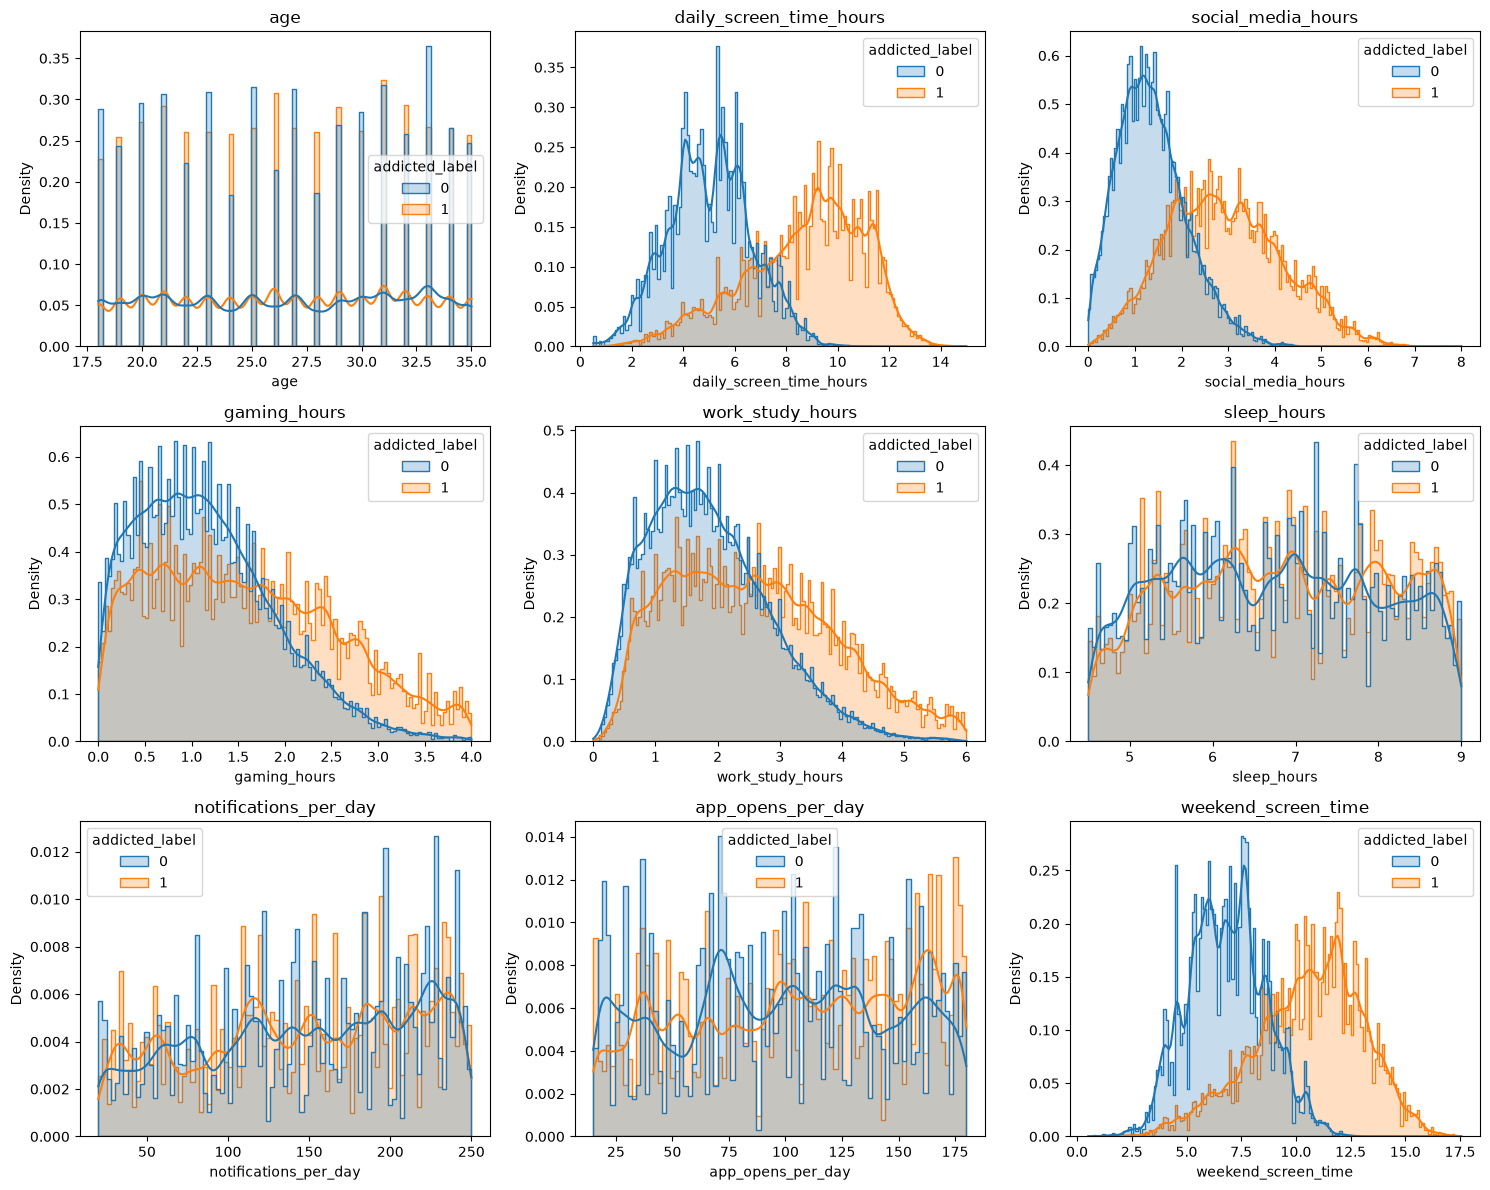

In [9]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(data=train, x=col, hue=TARGET, kde=True, ax=axes[i], element="step", stat="density", common_norm=False)
    axes[i].set_title(col)

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Correlation

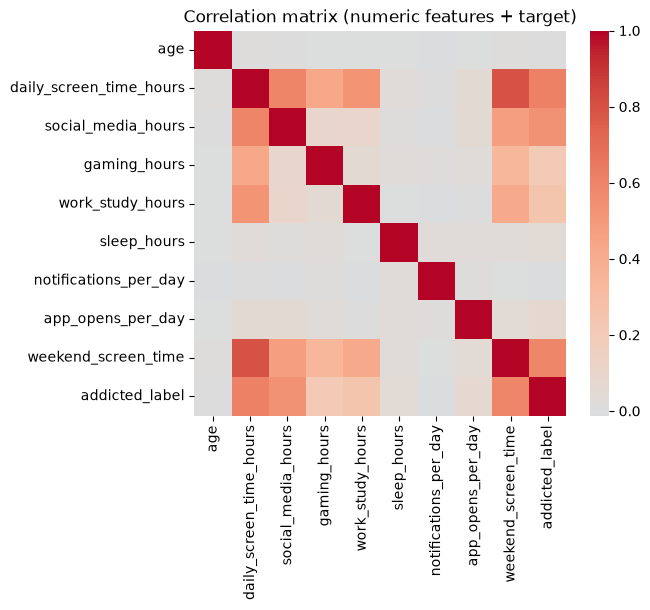

addicted_label             1.000000
daily_screen_time_hours    0.611398
weekend_screen_time        0.589903
social_media_hours         0.532409
work_study_hours           0.251416
gaming_hours               0.205283
app_opens_per_day          0.063482
sleep_hours                0.042545
age                        0.004043
notifications_per_day     -0.011583
Name: addicted_label, dtype: float64


In [10]:
corr = train[numeric_features + [TARGET]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation matrix (numeric features + target)")
plt.show()

print(corr[TARGET].sort_values(ascending=False))

## Train vs Test distribution

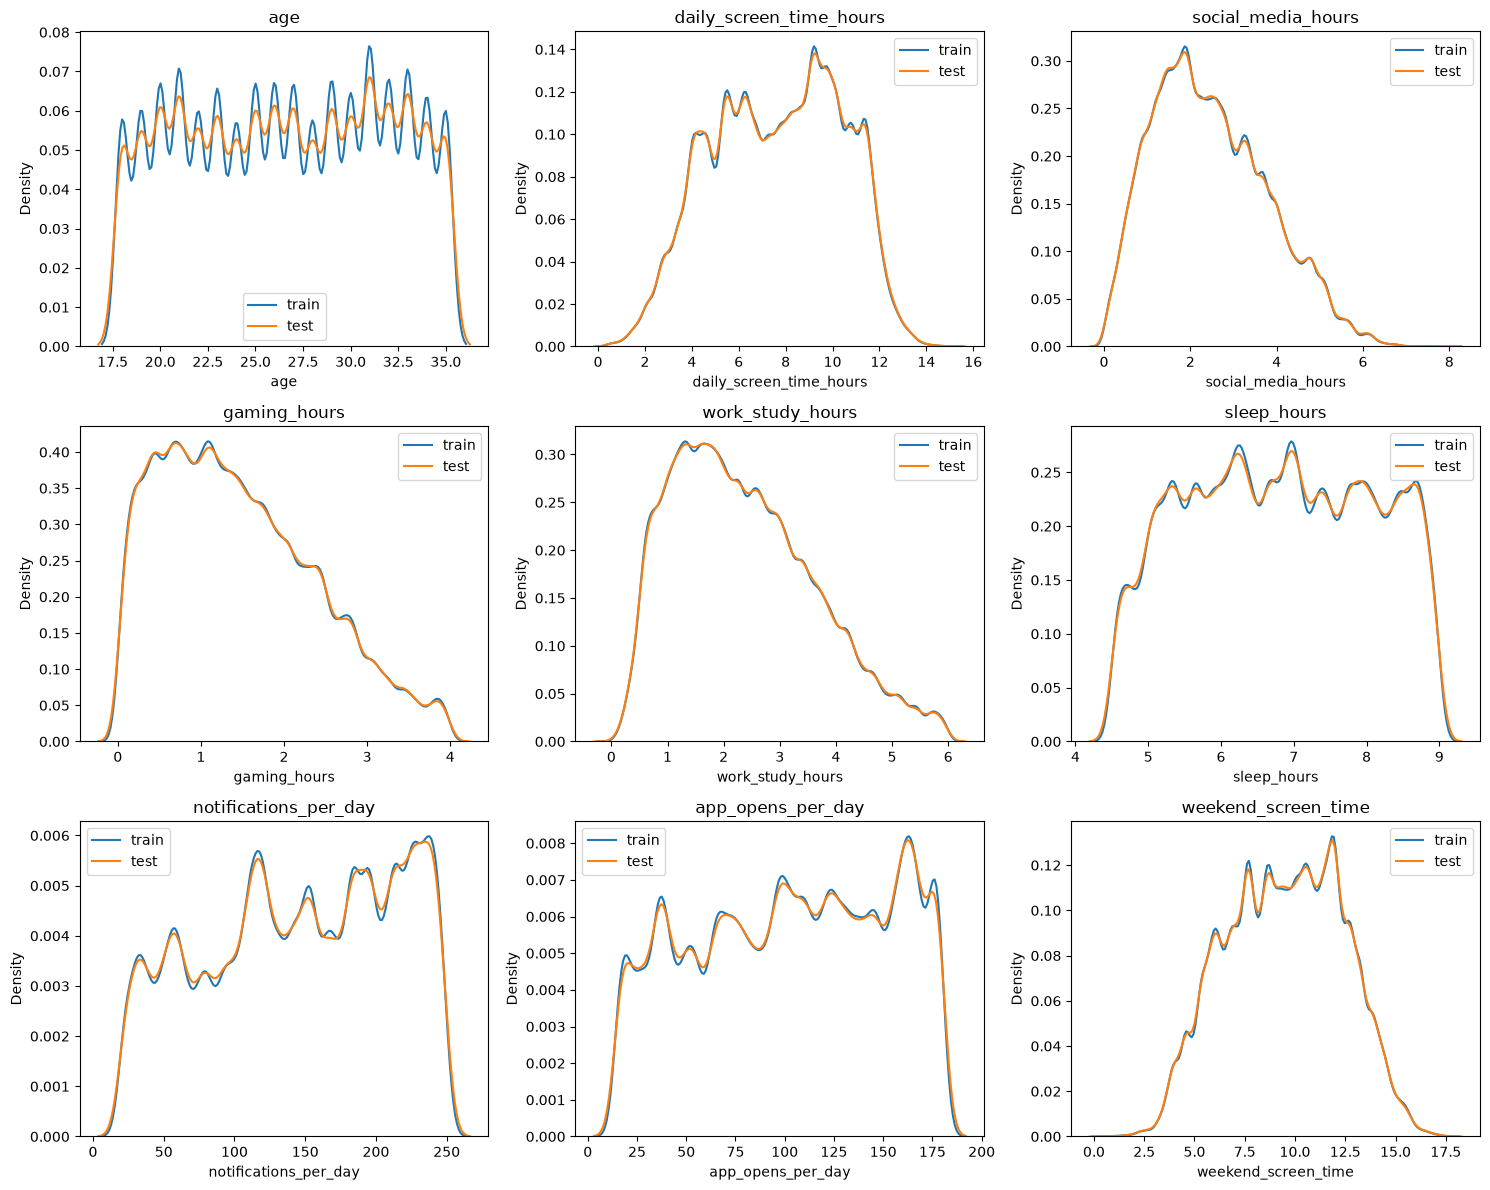

In [11]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.kdeplot(train[col], label="train", ax=axes[i])
    sns.kdeplot(test[col], label="test", ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend()

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [12]:
for col in feature_cols:
    if train[col].isnull().any():
        miss_rate = train[col].isnull().mean()
        target_when_missing = train.loc[train[col].isnull(), TARGET].mean()
        target_when_present = train.loc[train[col].notnull(), TARGET].mean()
        print(f"{col}: missing={miss_rate:.2%}, target|missing={target_when_missing:.3f}, target|present={target_when_present:.3f}")

age: missing=4.18%, target|missing=0.713, target|present=0.709
daily_screen_time_hours: missing=13.86%, target|missing=0.711, target|present=0.709
social_media_hours: missing=19.38%, target|missing=0.709, target|present=0.709
gaming_hours: missing=18.34%, target|missing=0.711, target|present=0.709
work_study_hours: missing=7.45%, target|missing=0.711, target|present=0.709
sleep_hours: missing=6.43%, target|missing=0.713, target|present=0.709
notifications_per_day: missing=9.78%, target|missing=0.710, target|present=0.709
app_opens_per_day: missing=11.67%, target|missing=0.713, target|present=0.709
weekend_screen_time: missing=16.21%, target|missing=0.711, target|present=0.709
gender: missing=4.20%, target|missing=0.709, target|present=0.709
stress_level: missing=7.98%, target|missing=0.709, target|present=0.709
academic_work_impact: missing=6.40%, target|missing=0.709, target|present=0.709


                         daily_screen_time_hours  social_media_hours  \
daily_screen_time_hours                 1.000000            0.595578   
social_media_hours                      0.595578            1.000000   
gaming_hours                            0.429343            0.088203   
work_study_hours                        0.525948            0.100520   
weekend_screen_time                     0.800061            0.478053   

                         gaming_hours  work_study_hours  weekend_screen_time  
daily_screen_time_hours      0.429343          0.525948             0.800061  
social_media_hours           0.088203          0.100520             0.478053  
gaming_hours                 1.000000          0.048995             0.342106  
work_study_hours             0.048995          1.000000             0.417525  
weekend_screen_time          0.342106          0.417525             1.000000  


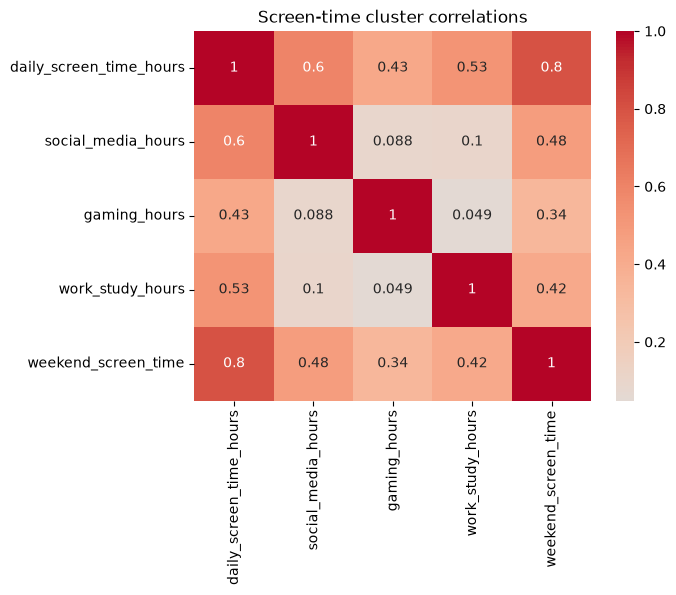

In [13]:
screen_time_cols = ["daily_screen_time_hours", "social_media_hours", "gaming_hours",
                     "work_study_hours", "weekend_screen_time"]

print(train[screen_time_cols].corr())

sns.heatmap(train[screen_time_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Screen-time cluster correlations")
plt.show()

## VIF for checking for multicollinearity

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = train[numeric_features].dropna()
vif_df = pd.DataFrame()
vif_df["feature"] = vif_data.columns
vif_df["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
print(vif_df.sort_values("VIF", ascending=False))

                   feature        VIF
1  daily_screen_time_hours  46.198557
8      weekend_screen_time  32.177299
5              sleep_hours  20.070690
0                      age  18.933473
2       social_media_hours   8.675134
4         work_study_hours   7.718411
6    notifications_per_day   5.561083
7        app_opens_per_day   5.337191
3             gaming_hours   4.977067


## Boxplots for detecting outliers

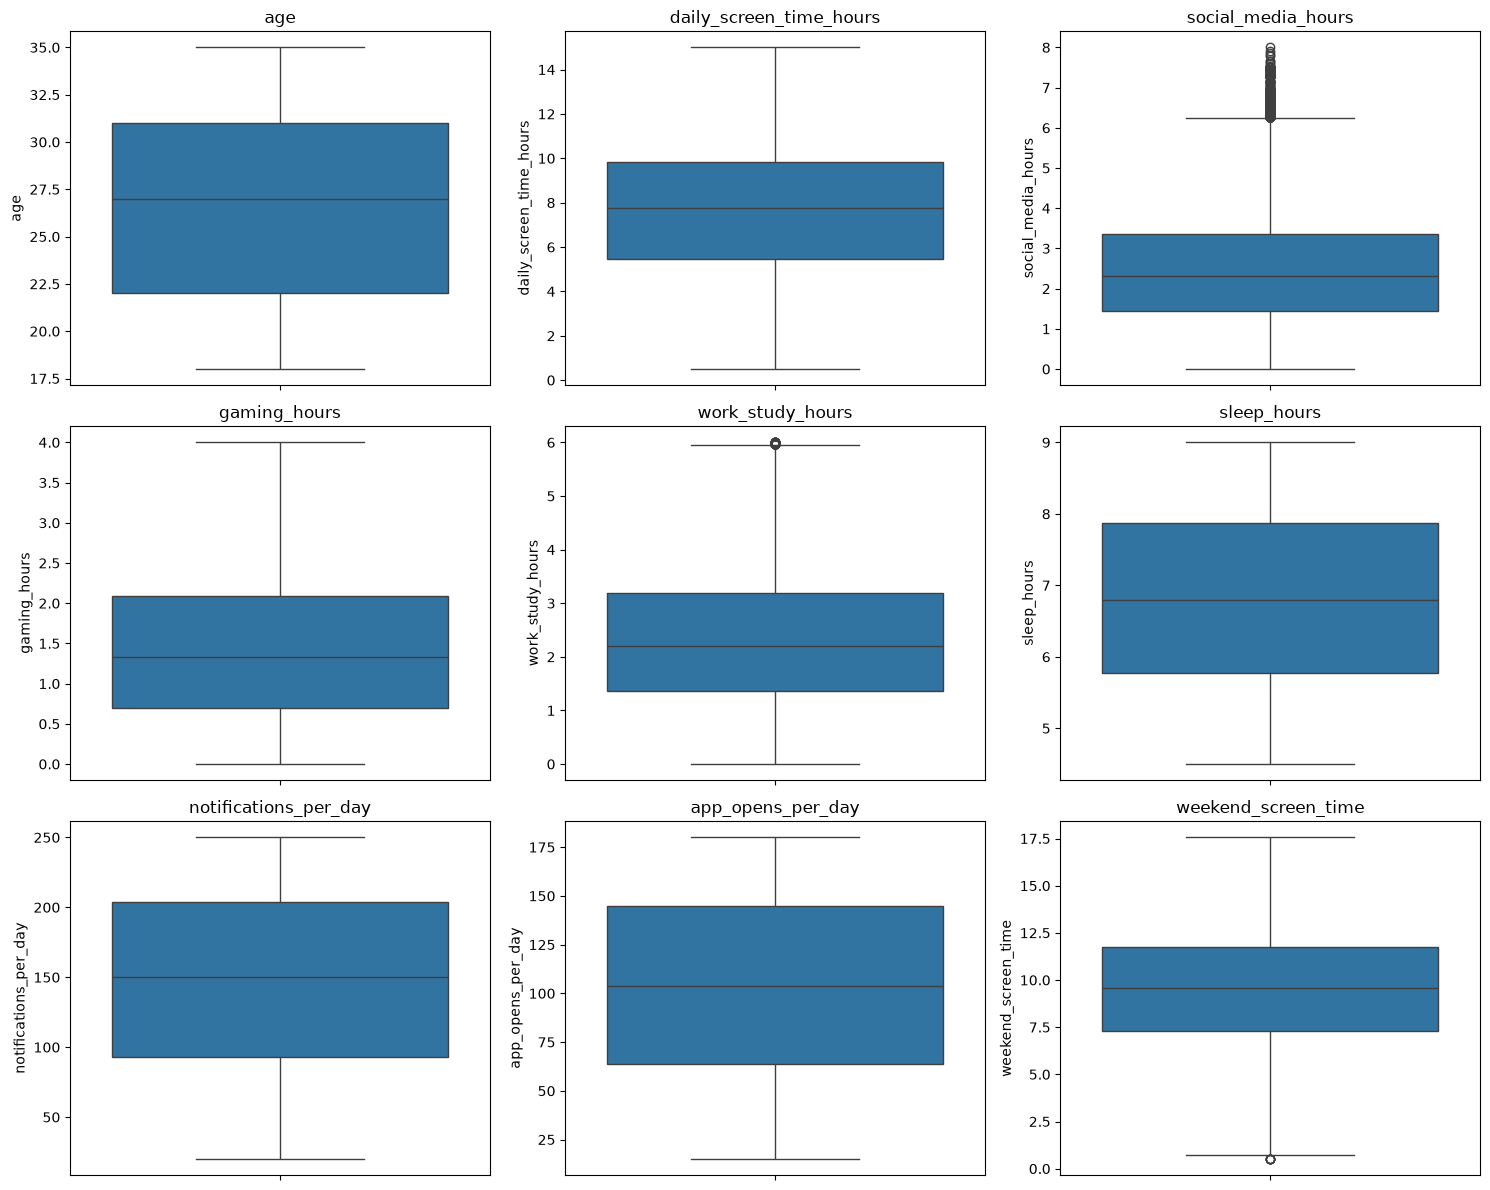

In [15]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(data=train, y=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Skewness

In [16]:
skew_vals = train[numeric_features].skew().sort_values(ascending=False)
print(skew_vals)

work_study_hours           0.563457
gaming_hours               0.544740
social_media_hours         0.468081
sleep_hours               -0.006587
age                       -0.036801
weekend_screen_time       -0.063408
app_opens_per_day         -0.126463
daily_screen_time_hours   -0.131972
notifications_per_day     -0.206535
dtype: float64
